In [ ]:
!pip -q install statsmodels openpyxl

import os
import time
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
from scipy import stats

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = (300, 300)
BATCH_SIZE = 16
N_SPLITS = 5

# First use 3 epochs only to check the code.
# After successful run, change this to 30.
EPOCHS = 3

print("=" * 70)
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))
print("=" * 70)

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os
def find_dataset_folder(base_dir="/content/drive/MyDrive"):
    possible_dirs = []

    for root, dirs, files in os.walk(base_dir):
        dir_names_lower = [d.lower() for d in dirs]

        if "benign" in dir_names_lower and "malignant" in dir_names_lower:
            possible_dirs.append(root)

    if len(possible_dirs) == 0:
        raise FileNotFoundError(
            "Could not find a folder containing both 'benign' and 'malignant'. "
            "Please check your Google Drive dataset path."
        )

    print("Possible dataset folders found:")
    for i, d in enumerate(possible_dirs):
        print(i, ":", d)

    return possible_dirs[0]


DRIVE_DATA_DIR = find_dataset_folder("/content/drive/MyDrive")

print("\nSelected Google Drive dataset folder:")
print(DRIVE_DATA_DIR)

print("\nFolders inside selected folder:")
print(os.listdir(DRIVE_DATA_DIR))

Possible dataset folders found:
0 : /content/drive/MyDrive/IDRI

Selected Google Drive dataset folder:
/content/drive/MyDrive/IDRI

Folders inside selected folder:
['Malignant', 'Benign']


In [ ]:
LOCAL_DATA_DIR = "/content/IDRI"

if not os.path.exists(LOCAL_DATA_DIR):
    print("Copying dataset from Google Drive to Colab local storage...")
    shutil.copytree(DRIVE_DATA_DIR, LOCAL_DATA_DIR)
    print("Copy completed.")
else:
    print("Local dataset already exists. Skipping copy.")

DATA_DIR = LOCAL_DATA_DIR

print("\nUsing DATA_DIR:")
print(DATA_DIR)

print("\nFolders inside DATA_DIR:")
print(os.listdir(DATA_DIR))

Copying dataset from Google Drive to Colab local storage...
Copy completed.

Using DATA_DIR:
/content/IDRI

Folders inside DATA_DIR:
['Malignant', 'Benign']


In [ ]:
def load_paths_and_labels_auto(data_dir):
    data_dir = Path(data_dir)

    if not data_dir.exists():
        raise FileNotFoundError(f"Dataset folder not found: {data_dir}")

    class_dirs = sorted([p for p in data_dir.iterdir() if p.is_dir()])

    if len(class_dirs) == 0:
        raise ValueError(f"No class folders found inside {data_dir}")

    print("Detected class folders:")
    for idx, class_dir in enumerate(class_dirs):
        print(idx, ":", class_dir.name)

    image_paths = []
    labels = []

    valid_ext = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"]

    for label, class_dir in enumerate(class_dirs):
        files = []

        for ext in valid_ext:
            files.extend(list(class_dir.glob(f"*{ext}")))
            files.extend(list(class_dir.glob(f"*{ext.upper()}")))

        print(class_dir.name, ":", len(files), "images")

        for f in files:
            image_paths.append(str(f))
            labels.append(label)

    image_paths = np.array(image_paths)
    labels = np.array(labels)

    print("\nTotal images found:", len(image_paths))

    if len(image_paths) == 0:
        raise ValueError("No images found. Check DATA_DIR and image extensions.")

    return image_paths, labels, [p.name for p in class_dirs]


image_paths, labels, detected_classes = load_paths_and_labels_auto(DATA_DIR)

print("\nFinal check:")
print("image_paths shape:", image_paths.shape)
print("labels shape:", labels.shape)

for i, cls in enumerate(detected_classes):
    print(f"Class {i} ({cls}) count:", np.sum(labels == i))

Detected class folders:
0 : Benign
1 : Malignant
Benign : 1139 images
Malignant : 1139 images

Total images found: 2278

Final check:
image_paths shape: (2278,)
labels shape: (2278,)
Class 0 (Benign) count: 1139
Class 1 (Malignant) count: 1139


In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name="training_augmentation")


def read_image(path, label, augment=False):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image = image / 255.0

    if augment:
        image = data_augmentation(image, training=True)

    return image, tf.cast(label, tf.float32)


def make_dataset(paths, y, batch_size, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, y))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(
        lambda p, l: read_image(p, l, augment=augment),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return ds

In [ ]:
def bilinear_first_order(b0_s, b1_s, a0_s, a1_s, K, Ts):
    c = 2.0 / Ts

    num0 = b0_s + b1_s * c
    num1 = b0_s - b1_s * c

    den0 = a0_s + a1_s * c
    den1 = a0_s - a1_s * c

    B0 = K * num0 / den0
    B1 = K * num1 / den0
    A1 = den1 / den0

    return B0, B1, A1


def get_lag_lead_coefficients(
    K=1.0,
    T1=0.2,
    beta=5.0,
    T2=0.1,
    alpha=0.2,
    Ts=1.0
):
    B0_lag, B1_lag, A1_lag = bilinear_first_order(
        b0_s=1.0,
        b1_s=T1,
        a0_s=1.0,
        a1_s=T1 * beta,
        K=K,
        Ts=Ts
    )

    B0_lead, B1_lead, A1_lead = bilinear_first_order(
        b0_s=1.0,
        b1_s=T2,
        a0_s=1.0,
        a1_s=alpha * T2,
        K=K,
        Ts=Ts
    )

    return {
        "B0_lag": B0_lag,
        "B1_lag": B1_lag,
        "A1_lag": A1_lag,
        "B0_lead": B0_lead,
        "B1_lead": B1_lead,
        "A1_lead": A1_lead
    }

In [ ]:
class LagFilter(layers.Layer):
    def __init__(self, B0, B1, **kwargs):
        super().__init__(**kwargs)
        self.B0 = float(B0)
        self.B1 = float(B1)

    def build(self, input_shape):
        channels = int(input_shape[-1])

        kernel_val = np.array([[self.B1, self.B0]], dtype=np.float32)
        kernel_val = np.stack(
            [kernel_val[:, :, np.newaxis]] * channels,
            axis=2
        )

        self.kernel = self.add_weight(
            name="lag_kernel",
            shape=(1, 2, channels, 1),
            initializer=tf.keras.initializers.Constant(kernel_val),
            trainable=False
        )

    def call(self, x):
        return tf.nn.depthwise_conv2d(
            x,
            self.kernel,
            strides=[1, 1, 1, 1],
            padding="SAME",
            data_format="NHWC"
        )


class LeadFilter(layers.Layer):
    def __init__(self, B0, B1, **kwargs):
        super().__init__(**kwargs)
        self.B0 = float(B0)
        self.B1 = float(B1)

    def build(self, input_shape):
        channels = int(input_shape[-1])

        kernel_val = np.array([[self.B1, self.B0]], dtype=np.float32)
        kernel_val = np.stack(
            [kernel_val[:, :, np.newaxis]] * channels,
            axis=2
        )

        self.kernel = self.add_weight(
            name="lead_kernel",
            shape=(1, 2, channels, 1),
            initializer=tf.keras.initializers.Constant(kernel_val),
            trainable=False
        )

    def call(self, x):
        return tf.nn.depthwise_conv2d(
            x,
            self.kernel,
            strides=[1, 1, 1, 1],
            padding="SAME",
            data_format="NHWC"
        )


class LagLeadModule(layers.Layer):
    def __init__(self, coeffs, **kwargs):
        super().__init__(**kwargs)
        self.lag = LagFilter(coeffs["B0_lag"], coeffs["B1_lag"])
        self.lead = LeadFilter(coeffs["B0_lead"], coeffs["B1_lead"])
        self.activation = layers.Activation("swish")

    def call(self, x):
        x = self.lag(x)
        x = self.lead(x)
        x = self.activation(x)
        return x

In [ ]:
class MBConvBlockWithLagLead(layers.Layer):
    def __init__(
        self,
        input_filters,
        output_filters,
        coeffs,
        expand_ratio=1,
        kernel_size=3,
        strides=1,
        se_ratio=0.25,
        drop_rate=0.0,
        activation="swish",
        **kwargs
    ):
        super().__init__(**kwargs)

        filters = input_filters * expand_ratio

        self.has_expansion = expand_ratio != 1
        self.has_skip = (strides == 1 and input_filters == output_filters)
        self.activation = layers.Activation(activation)

        if self.has_expansion:
            self.expand_conv = layers.Conv2D(
                filters,
                kernel_size=1,
                padding="same",
                use_bias=False,
                kernel_initializer="he_normal"
            )
            self.expand_bn = layers.BatchNormalization(axis=3)

        self.dwconv = layers.DepthwiseConv2D(
            kernel_size=kernel_size,
            strides=strides,
            padding="same",
            use_bias=False,
            depthwise_initializer="he_normal"
        )

        self.dwconv_bn = layers.BatchNormalization(axis=3)

        # Lag-Lead placement:
        # after depthwise convolution and before SE
        self.lag_lead = LagLeadModule(coeffs, name="lag_lead_compensator")

        self.se_gap = layers.GlobalAveragePooling2D()
        self.se_reshape = layers.Reshape((1, 1, filters))

        self.se_reduce = layers.Conv2D(
            max(1, int(filters * se_ratio)),
            kernel_size=1,
            padding="same",
            activation=activation,
            use_bias=True,
            kernel_initializer="he_normal"
        )

        self.se_expand = layers.Conv2D(
            filters,
            kernel_size=1,
            padding="same",
            activation="sigmoid",
            use_bias=True,
            kernel_initializer="he_normal"
        )

        self.se_mul = layers.Multiply()

        self.project_conv = layers.Conv2D(
            output_filters,
            kernel_size=1,
            padding="same",
            use_bias=False,
            kernel_initializer="he_normal"
        )

        self.project_bn = layers.BatchNormalization(axis=3)

        self.dropout = layers.Dropout(drop_rate) if drop_rate > 0 else None
        self.skip_add = layers.Add() if self.has_skip else None

    def call(self, inputs, training=None):
        x = inputs

        if self.has_expansion:
            x = self.expand_conv(x)
            x = self.expand_bn(x, training=training)
            x = self.activation(x)

        x = self.dwconv(x)
        x = self.dwconv_bn(x, training=training)
        x = self.activation(x)

        x = self.lag_lead(x)

        se = self.se_gap(x)
        se = self.se_reshape(se)
        se = self.se_reduce(se)
        se = self.se_expand(se)

        x = self.se_mul([x, se])

        x = self.project_conv(x)
        x = self.project_bn(x, training=training)

        if self.has_skip:
            if self.dropout is not None:
                x = self.dropout(x, training=training)
            x = self.skip_add([x, inputs])

        return x


def build_laglead_efficientnetb3(
    input_shape=(300, 300, 3),
    K=1.0,
    T1=0.2,
    T2=0.1,
    beta=5.0,
    alpha=0.2,
    Ts=1.0
):
    coeffs = get_lag_lead_coefficients(
        K=K,
        T1=T1,
        beta=beta,
        T2=T2,
        alpha=alpha,
        Ts=Ts
    )

    inputs = layers.Input(shape=input_shape)
    x = inputs

    x = layers.Conv2D(40, 3, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(axis=3)(x)
    x = layers.Activation("swish")(x)

    blocks_config = [
        (40,  24,  1, 3, 1, 0.25, 1),
        (24,  32,  6, 3, 2, 0.25, 2),
        (32,  48,  6, 5, 2, 0.25, 2),
        (48,  96,  6, 3, 2, 0.25, 3),
        (96,  136, 6, 5, 1, 0.25, 3),
        (136, 232, 6, 5, 2, 0.25, 4),
        (232, 384, 6, 3, 1, 0.25, 1),
    ]

    block_num = 0

    for input_f, output_f, expand_r, k_size, stride, se_r, repeats in blocks_config:
        for i in range(repeats):
            s = stride if i == 0 else 1
            in_f = input_f if i == 0 else output_f

            x = MBConvBlockWithLagLead(
                input_filters=in_f,
                output_filters=output_f,
                coeffs=coeffs,
                expand_ratio=expand_r,
                kernel_size=k_size,
                strides=s,
                se_ratio=se_r,
                drop_rate=0.0,
                name=f"block{block_num + 1}{chr(97 + i)}"
            )(x)

        block_num += 1

    x = layers.Conv2D(1536, 1, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization(axis=3)(x)
    x = layers.Activation("swish")(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs, name="LagLead_MBConv_EfficientNetB3")

    return model


def compile_model(model):
    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model

In [ ]:
def evaluate_predictions(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp + 1e-8)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall_sensitivity": rec,
        "specificity": specificity,
        "f1": f1,
        "auc": auc,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


def mean_sd_ci(values, confidence=0.95):
    values = np.array(values, dtype=float)
    values = values[~np.isnan(values)]

    mean = np.mean(values)
    sd = np.std(values, ddof=1)

    if len(values) > 1:
        sem = stats.sem(values)

        ci_low, ci_high = stats.t.interval(
            confidence,
            df=len(values) - 1,
            loc=mean,
            scale=sem
        )
    else:
        ci_low, ci_high = np.nan, np.nan

    return mean, sd, ci_low, ci_high

In [ ]:
def run_5fold_cv(
    T1=0.2,
    T2=0.1,
    K=1.0,
    beta=5.0,
    alpha=0.2,
    Ts=1.0,
    epochs=30,
    save_prefix="LagLead_MBConv"
):
    print("\n" + "=" * 80)
    print("5-FOLD CROSS-VALIDATION STARTED")
    print("=" * 80)

    print("Parameter details")
    print("-" * 80)
    print(f"K     = {K}")
    print(f"T1    = {T1}")
    print(f"T2    = {T2}")
    print(f"beta  = {beta}")
    print(f"alpha = {alpha}")
    print(f"Ts    = {Ts}")
    print(f"Epochs per fold = {epochs}")
    print(f"Number of folds = {N_SPLITS}")
    print("=" * 80)

    coeffs = get_lag_lead_coefficients(K, T1, beta, T2, alpha, Ts)

    print("Derived Lag-Lead digital coefficients")
    print("-" * 80)
    print(f"Lag  B0 = {coeffs['B0_lag']:.6f}")
    print(f"Lag  B1 = {coeffs['B1_lag']:.6f}")
    print(f"Lag  A1 = {coeffs['A1_lag']:.6f}")
    print(f"Lead B0 = {coeffs['B0_lead']:.6f}")
    print(f"Lead B1 = {coeffs['B1_lead']:.6f}")
    print(f"Lead A1 = {coeffs['A1_lead']:.6f}")
    print("=" * 80)

    experiment_start_time = time.time()
    experiment_start_datetime = datetime.now()

    print("Experiment start time:", experiment_start_datetime)

    skf = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=SEED
    )

    fold_results = []
    all_y_true = []
    all_y_prob = []
    all_y_pred = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(image_paths, labels), start=1):

        fold_start_time = time.time()
        fold_start_datetime = datetime.now()

        print("\n" + "=" * 80)
        print(f"FOLD {fold}/{N_SPLITS} STARTED")
        print("=" * 80)
        print("Fold start time:", fold_start_datetime)

        X_train, X_test = image_paths[train_idx], image_paths[test_idx]
        y_train, y_test = labels[train_idx], labels[test_idx]

        print("Training images:", len(X_train))
        print("Testing/held-out fold images:", len(X_test))
        print("Train class 0:", np.sum(y_train == 0))
        print("Train class 1:", np.sum(y_train == 1))
        print("Test class 0:", np.sum(y_test == 0))
        print("Test class 1:", np.sum(y_test == 1))

        train_ds = make_dataset(
            X_train,
            y_train,
            batch_size=BATCH_SIZE,
            augment=True,
            shuffle=True
        )

        test_ds = make_dataset(
            X_test,
            y_test,
            batch_size=BATCH_SIZE,
            augment=False,
            shuffle=False
        )

        tf.keras.backend.clear_session()

        model = build_laglead_efficientnetb3(
            input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
            K=K,
            T1=T1,
            T2=T2,
            beta=beta,
            alpha=alpha,
            Ts=Ts
        )

        model = compile_model(model)

        checkpoint_path = f"{save_prefix}_T1_{T1}_T2_{T2}_fold_{fold}.keras"

        callbacks = [
            ModelCheckpoint(
                checkpoint_path,
                monitor="val_auc",
                mode="max",
                save_best_only=True,
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor="val_auc",
                mode="max",
                factor=0.5,
                patience=5,
                min_lr=1e-7,
                verbose=1
            ),
            EarlyStopping(
                monitor="val_auc",
                mode="max",
                patience=10,
                restore_best_weights=True,
               verbose=1
            )
        ]

        print("\nTraining started for Fold", fold)

        training_start_time = time.time()

        history = model.fit(
            train_ds,
            validation_data=test_ds,
            epochs=epochs,
            callbacks=callbacks,
            verbose=1
        )

        training_end_time = time.time()
        training_time = training_end_time - training_start_time

        print("\nTraining completed for Fold", fold)
        print("Fold training time: {:.2f} seconds".format(training_time))
        print("Fold training time: {:.2f} minutes".format(training_time / 60))

        dummy_input = np.random.rand(
            1,
            IMG_SIZE[0],
            IMG_SIZE[1],
            3
        ).astype(np.float32)

        inf_start = time.time()
        _ = model.predict(dummy_input, verbose=0)
        inf_end = time.time()

        inference_time = inf_end - inf_start

        print("Inference time for 1 image: {:.6f} seconds".format(inference_time))

        print("\nEvaluating held-out Fold", fold)

        y_prob = model.predict(test_ds, verbose=1).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        metrics = evaluate_predictions(y_test, y_prob)

        metrics["fold"] = fold
        metrics["T1"] = T1
        metrics["T2"] = T2
        metrics["K"] = K
        metrics["beta"] = beta
        metrics["alpha"] = alpha
        metrics["Ts"] = Ts
        metrics["epochs"] = epochs
        metrics["training_time_seconds"] = training_time
        metrics["training_time_minutes"] = training_time / 60
        metrics["inference_time_seconds"] = inference_time

        fold_end_time = time.time()
        fold_total_time = fold_end_time - fold_start_time

        metrics["fold_total_time_seconds"] = fold_total_time
        metrics["fold_total_time_minutes"] = fold_total_time / 60

        fold_results.append(metrics)

        all_y_true.extend(y_test.tolist())
        all_y_prob.extend(y_prob.tolist())
        all_y_pred.extend(y_pred.tolist())

        print("\nFold", fold, "Results")
        print("-" * 80)
        print("Accuracy:    {:.4f}".format(metrics["accuracy"]))
        print("Precision:   {:.4f}".format(metrics["precision"]))
        print("Recall:      {:.4f}".format(metrics["recall_sensitivity"]))
        print("Specificity: {:.4f}".format(metrics["specificity"]))
        print("F1-score:    {:.4f}".format(metrics["f1"]))
        print("AUC:         {:.4f}".format(metrics["auc"]))
        print("Fold end time:", datetime.now())
        print("Fold total execution time: {:.2f} minutes".format(fold_total_time / 60))
        print("=" * 80)

    experiment_end_time = time.time()
    experiment_end_datetime = datetime.now()
    experiment_total_time = experiment_end_time - experiment_start_time

    fold_df = pd.DataFrame(fold_results)

    summary_rows = []

    for metric in [
        "accuracy",
        "precision",
        "recall_sensitivity",
        "specificity",
        "f1",
        "auc",
        "training_time_minutes",
        "inference_time_seconds"
    ]:
        mean, sd, ci_low, ci_high = mean_sd_ci(fold_df[metric].values)

        summary_rows.append({
            "T1": T1,
            "T2": T2,
            "K": K,
            "beta": beta,
            "alpha": alpha,
            "Ts": Ts,
            "metric": metric,
            "mean": mean,
            "sd": sd,
            "ci95_low": ci_low,
            "ci95_high": ci_high
        })

    summary_df = pd.DataFrame(summary_rows)

    print("\n" + "=" * 80)
    print("5-FOLD CROSS-VALIDATION COMPLETED")
    print("=" * 80)
    print("Experiment start time:", experiment_start_datetime)
    print("Experiment end time:", experiment_end_datetime)
    print("Total execution time: {:.2f} seconds".format(experiment_total_time))
    print("Total execution time: {:.2f} minutes".format(experiment_total_time / 60))
    print("Total execution time: {:.2f} hours".format(experiment_total_time / 3600))
    print("=" * 80)

    return fold_df, summary_df, np.array(all_y_true), np.array(all_y_pred), np.array(all_y_prob)

In [ ]:
main_fold_df, main_summary_df, y_true_main, y_pred_main, y_prob_main = run_5fold_cv(
    T1=0.2,
    T2=0.1,
    K=1.0,
    beta=5.0,
    alpha=0.2,
    Ts=1.0,
    epochs=EPOCHS,
    save_prefix="LagLead_MBConv_Main"
)

print("\nPer-fold results")
display(main_fold_df)

print("\nSummary: mean, SD, 95% CI")
display(main_summary_df)


5-FOLD CROSS-VALIDATION STARTED
Parameter details
--------------------------------------------------------------------------------
K     = 1.0
T1    = 0.2
T2    = 0.1
beta  = 5.0
alpha = 0.2
Ts    = 1.0
Epochs per fold = 3
Number of folds = 5
Derived Lag-Lead digital coefficients
--------------------------------------------------------------------------------
Lag  B0 = 0.466667
Lag  B1 = 0.200000
Lag  A1 = -0.333333
Lead B0 = 1.153846
Lead B1 = 0.769231
Lead A1 = 0.923077
Experiment start time: 2026-06-03 04:45:25.466006

FOLD 1/5 STARTED
Fold start time: 2026-06-03 04:45:25.489461
Training images: 1822
Testing/held-out fold images: 456
Train class 0: 911
Train class 1: 911
Test class 0: 228
Test class 1: 228

Training started for Fold 1
Epoch 1/3
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 921ms/step - accuracy: 0.4966 - auc: 0.5112 - loss: 0.9165 - precision: 0.4837 - recall: 0.5040
Epoch 1: val_auc improved from None to 0.50000, saving model to LagLead_MBConv_Main_T1_0.2_T2_0.1_fold_1.keras

E

,accuracy,precision,recall_sensitivity,specificity,f1,auc,tn,fp,fn,tp,...,K,beta,alpha,Ts,epochs,training_time_seconds,training_time_minutes,inference_time_seconds,fold_total_time_seconds,fold_total_time_minutes
0,0.500000,0.500000,1.0,0.0,0.666667,0.489035,0,228,0,228,...,1.0,5.0,0.2,1.0,3,332.420219,5.540337,15.833704,379.897503,6.331625
1,0.500000,0.000000,0.0,1.0,0.000000,0.500000,228,0,228,0,...,1.0,5.0,0.2,1.0,3,346.717541,5.778626,9.066702,380.666171,6.344436
2,0.500000,0.500000,1.0,0.0,0.666667,0.500000,0,228,0,228,...,1.0,5.0,0.2,1.0,3,319.299377,5.321656,9.194460,352.804556,5.880076
3,0.498901,0.498901,1.0,0.0,0.665689,0.501739,0,228,0,227,...,1.0,5.0,0.2,1.0,3,314.436613,5.240610,8.824111,348.557707,5.809295
4,0.498901,0.000000,0.0,1.0,0.000000,0.506482,227,0,228,0,...,1.0,5.0,0.2,1.0,3,283.993321,4.733222,9.763691,320.221920,5.337032



Summary: mean, SD, 95% CI


,T1,T2,K,beta,alpha,Ts,metric,mean,sd,ci95_low,ci95_high
0,0.2,0.1,1.0,5.0,0.2,1.0,accuracy,0.499560,0.000602,0.498813,0.500308
1,0.2,0.1,1.0,5.0,0.2,1.0,precision,0.299780,0.273661,-0.040015,0.639575
2,0.2,0.1,1.0,5.0,0.2,1.0,recall_sensitivity,0.600000,0.547723,-0.080087,1.280087
3,0.2,0.1,1.0,5.0,0.2,1.0,specificity,0.400000,0.547723,-0.280087,1.080087
4,0.2,0.1,1.0,5.0,0.2,1.0,f1,0.399804,0.364970,-0.053366,0.852975
5,0.2,0.1,1.0,5.0,0.2,1.0,auc,0.499451,0.006399,0.491506,0.507396
6,0.2,0.1,1.0,5.0,0.2,1.0,training_time_minutes,5.322890,0.390339,4.838220,5.807560
7,0.2,0.1,1.0,5.0,0.2,1.0,inference_time_seconds,10.536534,2.981244,6.834831,14.238236


In [ ]:
RESULTS_DIR = "/content/drive/MyDrive/LagLead_MBConv_Results"
os.makedirs(RESULTS_DIR, exist_ok=True)

main_fold_path = os.path.join(RESULTS_DIR, "per_fold_results_main.xlsx")
main_summary_path = os.path.join(RESULTS_DIR, "summary_95CI_main.xlsx")

main_fold_df.to_excel(main_fold_path, index=False)
main_summary_df.to_excel(main_summary_path, index=False)

print("Saved files:")
print(main_fold_path)
print(main_summary_path)

Saved files:
/content/drive/MyDrive/LagLead_MBConv_Results/per_fold_results_main.xlsx
/content/drive/MyDrive/LagLead_MBConv_Results/summary_95CI_main.xlsx


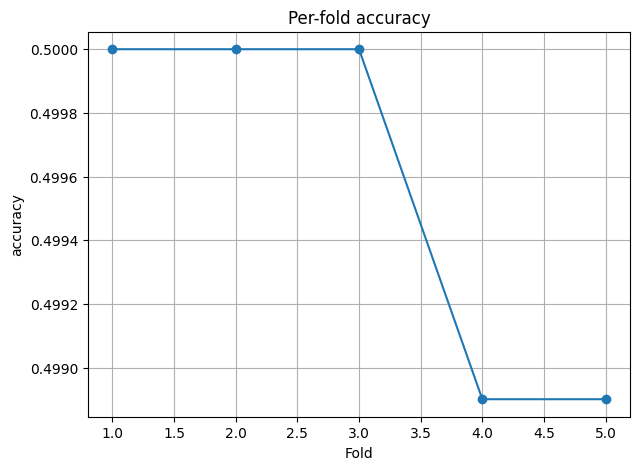

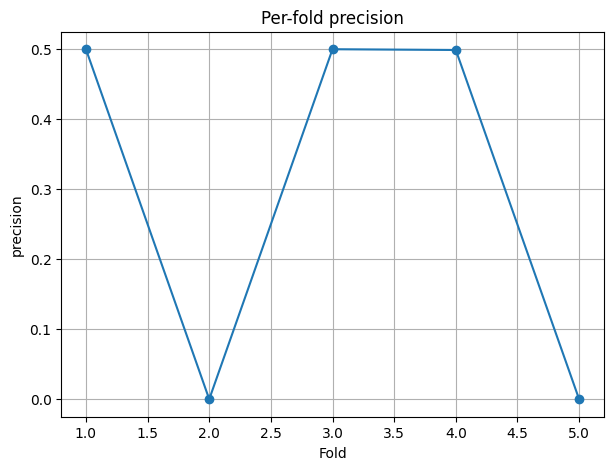

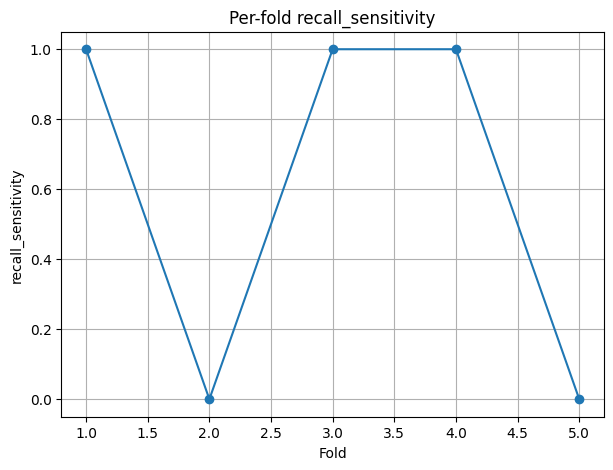

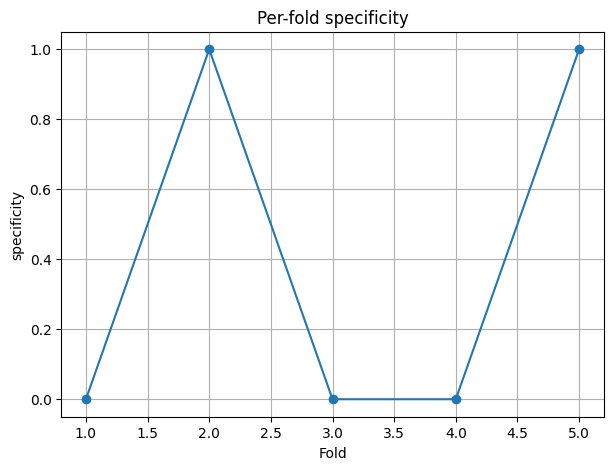

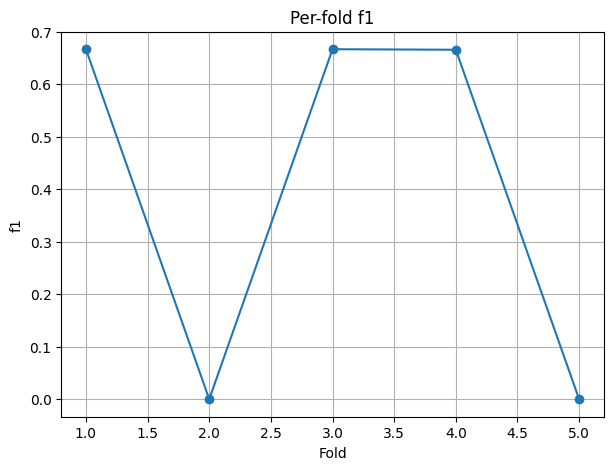

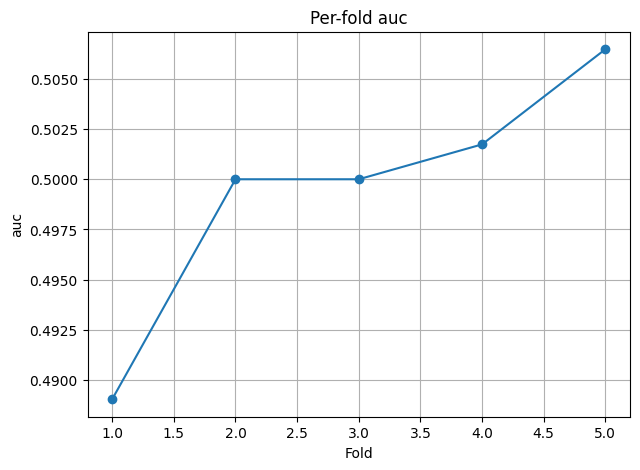

In [ ]:
metrics_to_plot = [
    "accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1",
    "auc"
]

for metric in metrics_to_plot:
    plt.figure(figsize=(7, 5))
    plt.plot(main_fold_df["fold"], main_fold_df[metric], marker="o")
    plt.xlabel("Fold")
    plt.ylabel(metric)
    plt.title(f"Per-fold {metric}")
    plt.grid(True)
    plt.show()

In [ ]:
def run_5fold_cv(
    T1=0.2,
    T2=0.1,
    K=1.0,
    beta=5.0,
    alpha=0.2,
    Ts=1.0,
    epochs=30,
    save_prefix="LagLead_MBConv"
):
    print("\n" + "=" * 80)
    print("5-FOLD CROSS-VALIDATION STARTED")
    print("=" * 80)

    print("Parameter details")
    print("-" * 80)
    print(f"K     = {K}")
    print(f"T1    = {T1}")
    print(f"T2    = {T2}")
    print(f"beta  = {beta}")
    print(f"alpha = {alpha}")
    print(f"Ts    = {Ts}")
    print(f"Epochs per fold = {epochs}")
    print(f"Number of folds = {N_SPLITS}")
    print("=" * 80)

    coeffs = get_lag_lead_coefficients(K, T1, beta, T2, alpha, Ts)

    print("Derived Lag-Lead digital coefficients")
    print("-" * 80)
    print(f"Lag  B0 = {coeffs['B0_lag']:.6f}")
    print(f"Lag  B1 = {coeffs['B1_lag']:.6f}")
    print(f"Lag  A1 = {coeffs['A1_lag']:.6f}")
    print(f"Lead B0 = {coeffs['B0_lead']:.6f}")
    print(f"Lead B1 = {coeffs['B1_lead']:.6f}")
    print(f"Lead A1 = {coeffs['A1_lead']:.6f}")
    print("=" * 80)

    experiment_start_time = time.time()
    experiment_start_datetime = datetime.now()

    print("Experiment start time:", experiment_start_datetime)

    skf = StratifiedKFold(
        n_splits=N_SPLITS,
        shuffle=True,
        random_state=SEED
    )

    fold_results = []
    all_y_true = []
    all_y_prob = []
    all_y_pred = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(image_paths, labels), start=1):

        fold_start_time = time.time()
        fold_start_datetime = datetime.now()

        print("\n" + "=" * 80)
        print(f"FOLD {fold}/{N_SPLITS} STARTED")
        print("=" * 80)
        print("Fold start time:", fold_start_datetime)

        X_train, X_test = image_paths[train_idx], image_paths[test_idx]
        y_train, y_test = labels[train_idx], labels[test_idx]

        print("Training images:", len(X_train))
        print("Testing/held-out fold images:", len(X_test))
        print("Train class 0:", np.sum(y_train == 0))
        print("Train class 1:", np.sum(y_train == 1))
        print("Test class 0:", np.sum(y_test == 0))
        print("Test class 1:", np.sum(y_test == 1))

        train_ds = make_dataset(
            X_train,
            y_train,
            batch_size=BATCH_SIZE,
            augment=True,
            shuffle=True
        )

        test_ds = make_dataset(
            X_test,
            y_test,
            batch_size=BATCH_SIZE,
            augment=False,
            shuffle=False
        )

        tf.keras.backend.clear_session()

        model = build_laglead_efficientnetb3(
            input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
            K=K,
            T1=T1,
            T2=T2,
            beta=beta,
            alpha=alpha,
            Ts=Ts
        )

        model = compile_model(model)

        checkpoint_path = f"{save_prefix}_T1_{T1}_T2_{T2}_fold_{fold}.keras"

        callbacks = [
            ModelCheckpoint(
                checkpoint_path,
                monitor="val_auc",
                mode="max",
                save_best_only=True,
                verbose=1
            ),
            ReduceLROnPlateau(
                monitor="val_auc",
                mode="max",
                factor=0.5,
                patience=5,
                min_lr=1e-7,
                verbose=1
            ),
            EarlyStopping(
                monitor="val_auc",
                mode="max",
                patience=10,
                restore_best_weights=True,
               verbose=1
            )
        ]

        print("\nTraining started for Fold", fold)

        training_start_time = time.time()

        history = model.fit(
            train_ds,
            validation_data=test_ds,
            epochs=epochs,
            callbacks=callbacks,
            verbose=1
        )

        training_end_time = time.time()
        training_time = training_end_time - training_start_time

        print("\nTraining completed for Fold", fold)
        print("Fold training time: {:.2f} seconds".format(training_time))
        print("Fold training time: {:.2f} minutes".format(training_time / 60))

        dummy_input = np.random.rand(
            1,
            IMG_SIZE[0],
            IMG_SIZE[1],
            3
        ).astype(np.float32)

        inf_start = time.time()
        _ = model.predict(dummy_input, verbose=0)
        inf_end = time.time()

        inference_time = inf_end - inf_start

        print("Inference time for 1 image: {:.6f} seconds".format(inference_time))

        print("\nEvaluating held-out Fold", fold)

        y_prob = model.predict(test_ds, verbose=1).ravel()
        y_pred = (y_prob >= 0.5).astype(int)

        metrics = evaluate_predictions(y_test, y_prob)

        metrics["fold"] = fold
        metrics["T1"] = T1
        metrics["T2"] = T2
        metrics["K"] = K
        metrics["beta"] = beta
        metrics["alpha"] = alpha
        metrics["Ts"] = Ts
        metrics["epochs"] = epochs
        metrics["training_time_seconds"] = training_time
        metrics["training_time_minutes"] = training_time / 60
        metrics["inference_time_seconds"] = inference_time

        fold_end_time = time.time()
        fold_total_time = fold_end_time - fold_start_time

        metrics["fold_total_time_seconds"] = fold_total_time
        metrics["fold_total_time_minutes"] = fold_total_time / 60

        fold_results.append(metrics)

        all_y_true.extend(y_test.tolist())
        all_y_prob.extend(y_prob.tolist())
        all_y_pred.extend(y_pred.tolist())

        print("\nFold", fold, "Results")
        print("-" * 80)
        print("Accuracy:    {:.4f}".format(metrics["accuracy"]))
        print("Precision:   {:.4f}".format(metrics["precision"]))
        print("Recall:      {:.4f}".format(metrics["recall_sensitivity"]))
        print("Specificity: {:.4f}".format(metrics["specificity"]))
        print("F1-score:    {:.4f}".format(metrics["f1"]))
        print("AUC:         {:.4f}".format(metrics["auc"]))
        print("Fold end time:", datetime.now())
        print("Fold total execution time: {:.2f} minutes".format(fold_total_time / 60))
        print("=" * 80)

    experiment_end_time = time.time()
    experiment_end_datetime = datetime.now()
    experiment_total_time = experiment_end_time - experiment_start_time

    fold_df = pd.DataFrame(fold_results)

    summary_rows = []

    for metric in [
        "accuracy",
        "precision",
        "recall_sensitivity",
        "specificity",
        "f1",
        "auc",
        "training_time_minutes",
        "inference_time_seconds"
    ]:
        mean, sd, ci_low, ci_high = mean_sd_ci(fold_df[metric].values)

        summary_rows.append({
            "T1": T1,
            "T2": T2,
            "K": K,
            "beta": beta,
            "alpha": alpha,
            "Ts": Ts,
            "metric": metric,
            "mean": mean,
            "sd": sd,
            "ci95_low": ci_low,
            "ci95_high": ci_high
        })

    summary_df = pd.DataFrame(summary_rows)

    print("\n" + "=" * 80)
    print("5-FOLD CROSS-VALIDATION COMPLETED")
    print("=" * 80)
    print("Experiment start time:", experiment_start_datetime)
    print("Experiment end time:", experiment_end_datetime)
    print("Total execution time: {:.2f} seconds".format(experiment_total_time))
    print("Total execution time: {:.2f} minutes".format(experiment_total_time / 60))
    print("Total execution time: {:.2f} hours".format(experiment_total_time / 3600))
    print("=" * 80)

    return fold_df, summary_df, np.array(all_y_true), np.array(all_y_pred), np.array(all_y_prob)

In [ ]:
main_fold_df, main_summary_df, y_true_main, y_pred_main, y_prob_main = run_5fold_cv(
    T1=0.2,
    T2=0.1,
    K=1.0,
    beta=5.0,
    alpha=0.2,
    Ts=1.0,
    epochs=30,
    save_prefix="LagLead_MBConv_Main"
)

print("\nPer-fold results")
display(main_fold_df)

print("\nSummary: mean, SD, 95% CI")
display(main_summary_df)


5-FOLD CROSS-VALIDATION STARTED
Parameter details
--------------------------------------------------------------------------------
K     = 1.0
T1    = 0.2
T2    = 0.1
beta  = 5.0
alpha = 0.2
Ts    = 1.0
Epochs per fold = 30
Number of folds = 5
Derived Lag-Lead digital coefficients
--------------------------------------------------------------------------------
Lag  B0 = 0.466667
Lag  B1 = 0.200000
Lag  A1 = -0.333333
Lead B0 = 1.153846
Lead B1 = 0.769231
Lead A1 = 0.923077
Experiment start time: 2026-06-03 09:13:31.611166

FOLD 1/5 STARTED
Fold start time: 2026-06-03 09:13:31.619552
Training images: 1822
Testing/held-out fold images: 456
Train class 0: 911
Train class 1: 911
Test class 0: 228
Test class 1: 228

Training started for Fold 1
Epoch 1/30
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.4940 - auc: 0.4826 - loss: 0.9495 - precision: 0.4798 - recall: 0.4743
Epoch 1: val_auc improved from None to 0.50000, saving model to LagLead_MBConv_Main_T1_0.2_T2_0.1_fold_1.keras


,accuracy,precision,recall_sensitivity,specificity,f1,auc,tn,fp,fn,tp,...,K,beta,alpha,Ts,epochs,training_time_seconds,training_time_minutes,inference_time_seconds,fold_total_time_seconds,fold_total_time_minutes
0,0.548246,0.591667,0.311404,0.785088,0.408046,0.598752,179,49,157,71,...,1.0,5.0,0.2,1.0,30,438.314141,7.305236,14.875350,476.348486,7.939141
1,0.530702,0.517766,0.894737,0.166667,0.655949,0.563654,38,190,24,204,...,1.0,5.0,0.2,1.0,30,293.039997,4.884000,7.333411,321.663083,5.361051
2,0.532895,0.520661,0.828947,0.236842,0.639594,0.623827,54,174,39,189,...,1.0,5.0,0.2,1.0,30,348.656471,5.810941,7.401565,378.022720,6.300379
3,0.582418,0.641221,0.370044,0.793860,0.469274,0.633579,181,47,143,84,...,1.0,5.0,0.2,1.0,30,422.030224,7.033837,7.273449,452.166096,7.536102
4,0.560440,0.535897,0.916667,0.202643,0.676375,0.645771,46,181,19,209,...,1.0,5.0,0.2,1.0,30,350.613244,5.843554,7.448802,380.989230,6.349821



Summary: mean, SD, 95% CI


,T1,T2,K,beta,alpha,Ts,metric,mean,sd,ci95_low,ci95_high
0,0.2,0.1,1.0,5.0,0.2,1.0,accuracy,0.550940,0.021352,0.524428,0.577451
1,0.2,0.1,1.0,5.0,0.2,1.0,precision,0.561443,0.053622,0.494862,0.628024
2,0.2,0.1,1.0,5.0,0.2,1.0,recall_sensitivity,0.664360,0.297918,0.294445,1.034274
3,0.2,0.1,1.0,5.0,0.2,1.0,specificity,0.437020,0.322715,0.036316,0.837724
4,0.2,0.1,1.0,5.0,0.2,1.0,f1,0.569848,0.122394,0.417876,0.721819
5,0.2,0.1,1.0,5.0,0.2,1.0,auc,0.613116,0.032606,0.572631,0.653602
6,0.2,0.1,1.0,5.0,0.2,1.0,training_time_minutes,6.175514,0.990468,4.945685,7.405342
7,0.2,0.1,1.0,5.0,0.2,1.0,inference_time_seconds,8.866515,3.359701,4.694896,13.038135


In [ ]:
RESULTS_DIR = "/content/drive/MyDrive/LagLead_MBConv_Results"
os.makedirs(RESULTS_DIR, exist_ok=True)

main_fold_path = os.path.join(RESULTS_DIR, "per_fold_results_main.xlsx")
main_summary_path = os.path.join(RESULTS_DIR, "summary_95CI_main.xlsx")

main_fold_df.to_excel(main_fold_path, index=False)
main_summary_df.to_excel(main_summary_path, index=False)

print("Saved files:")
print(main_fold_path)
print(main_summary_path)

Saved files:
/content/drive/MyDrive/LagLead_MBConv_Results/per_fold_results_main.xlsx
/content/drive/MyDrive/LagLead_MBConv_Results/summary_95CI_main.xlsx


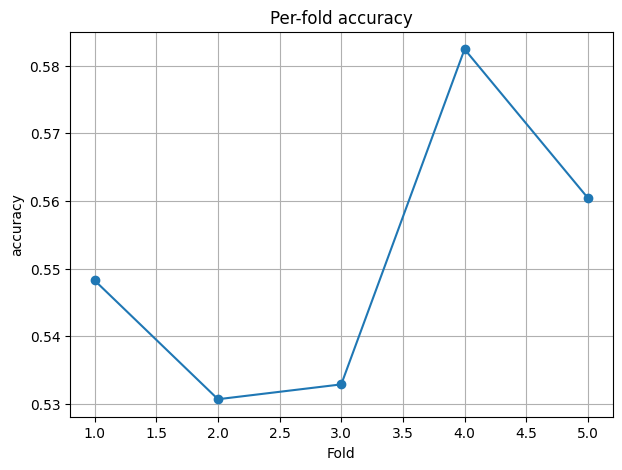

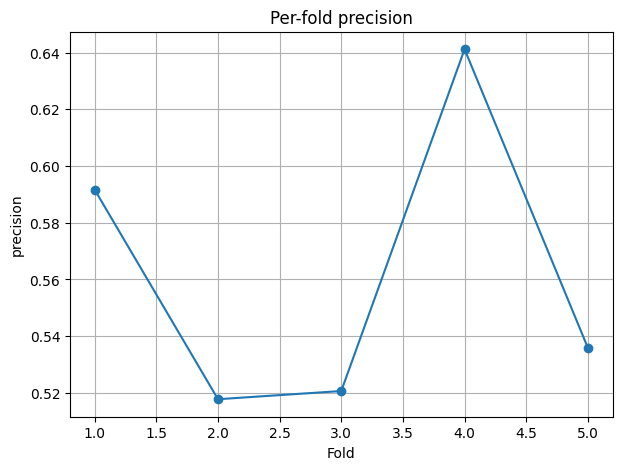

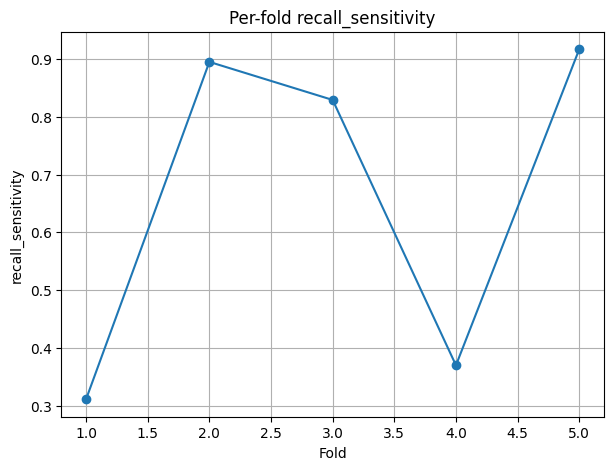

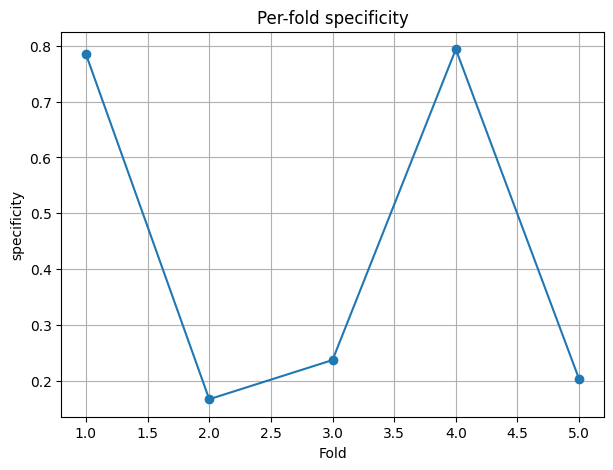

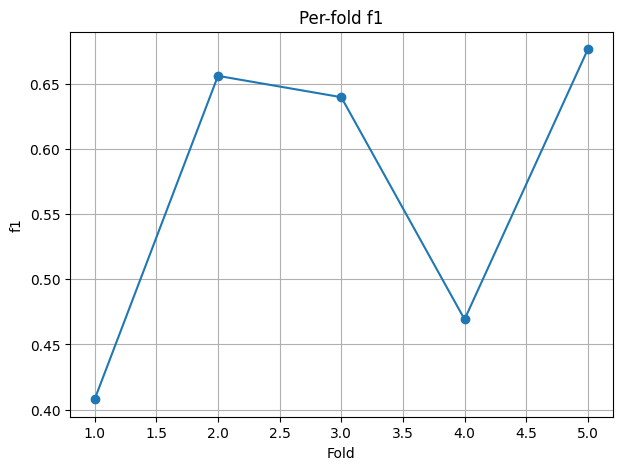

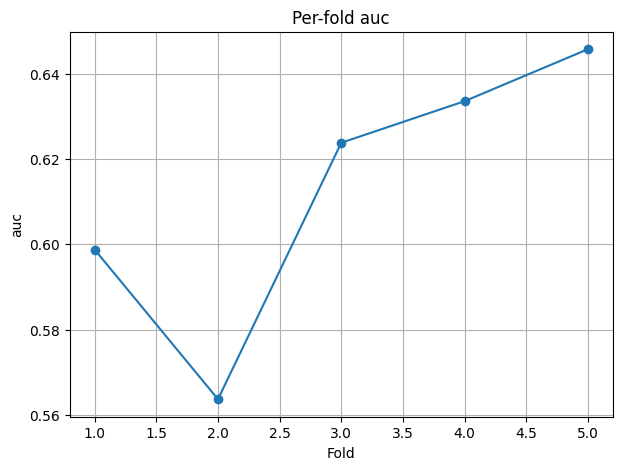

In [ ]:
metrics_to_plot = [
    "accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1",
    "auc"
]

for metric in metrics_to_plot:
    plt.figure(figsize=(7, 5))
    plt.plot(main_fold_df["fold"], main_fold_df[metric], marker="o")
    plt.xlabel("Fold")
    plt.ylabel(metric)
    plt.title(f"Per-fold {metric}")
    plt.grid(True)
    plt.show()

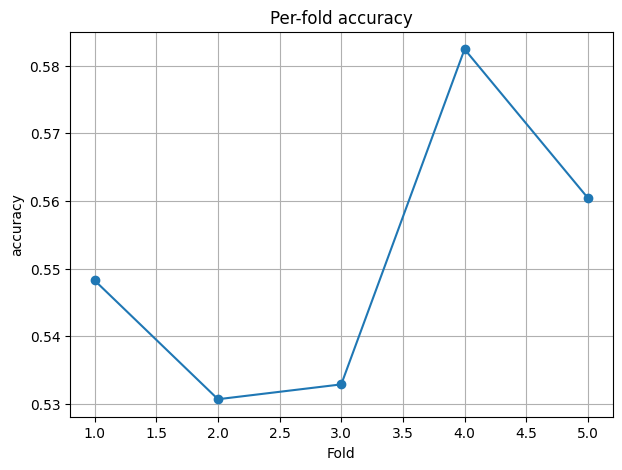

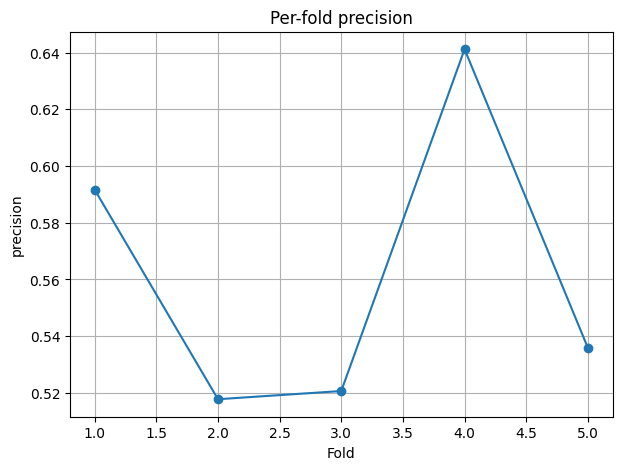

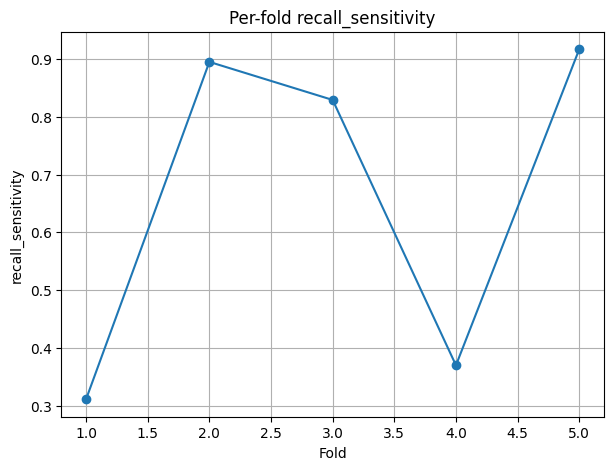

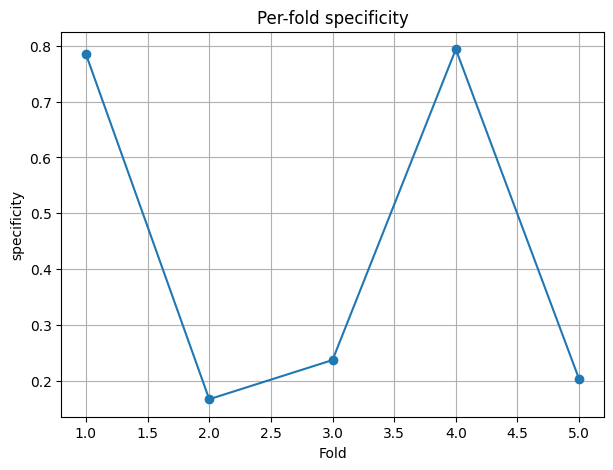

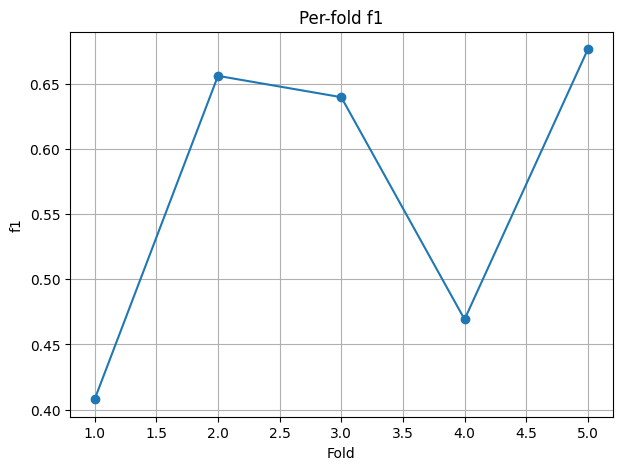

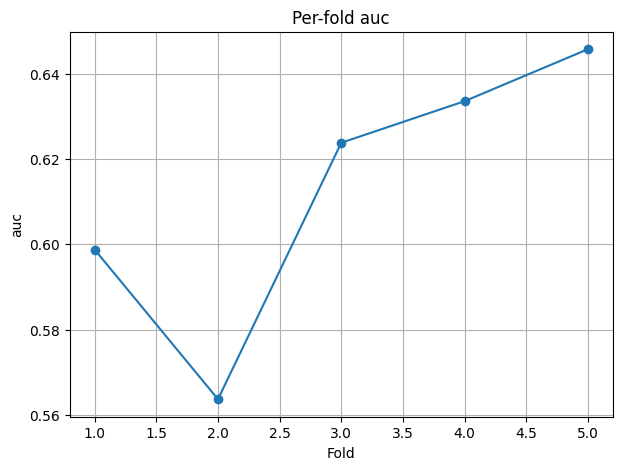

In [ ]:
metrics_to_plot = [
    "accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1",
    "auc"
]

for metric in metrics_to_plot:
    plt.figure(figsize=(7, 5))
    plt.plot(main_fold_df["fold"], main_fold_df[metric], marker="o")
    plt.xlabel("Fold")
    plt.ylabel(metric)
    plt.title(f"Per-fold {metric}")
    plt.grid(True)
    plt.show()

In [ ]:
# =========================================================
# CELL 15: COMBINED T1-T2 SENSITIVITY SETTINGS
# =========================================================

import os
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "/content/drive/MyDrive/LagLead_MBConv_Results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Smaller grid around selected values
T1_VALUES = [0.15, 0.20, 0.25]
T2_VALUES = [0.075, 0.10, 0.125]

# Use 5 first. Later use 10 or 30 if time allows.
SENS_EPOCHS = 5

print("Combined T1-T2 sensitivity settings")
print("T1 values:", T1_VALUES)
print("T2 values:", T2_VALUES)
print("Sensitivity epochs:", SENS_EPOCHS)
print("Results folder:", RESULTS_DIR)

Combined T1-T2 sensitivity settings
T1 values: [0.15, 0.2, 0.25]
T2 values: [0.075, 0.1, 0.125]
Sensitivity epochs: 5
Results folder: /content/drive/MyDrive/LagLead_MBConv_Results


In [ ]:
# =========================================================
# CELL 16: RUN COMBINED T1-T2 SENSITIVITY ANALYSIS
# =========================================================

combined_fold_tables = []
combined_summary_tables = []

for t1 in T1_VALUES:
    for t2 in T2_VALUES:

        print("\n" + "#" * 80)
        print(f"Running combined sensitivity: T1={t1}, T2={t2}")
        print("#" * 80)

        fold_df, summary_df, _, _, _ = run_5fold_cv(
            T1=t1,
            T2=t2,
            K=1.0,
            beta=5.0,
            alpha=0.2,
            Ts=1.0,
            epochs=SENS_EPOCHS,
            save_prefix=f"CombinedSensitivity_T1_{t1}_T2_{t2}"
        )

        fold_df["sensitivity_type"] = "combined_T1_T2"
        summary_df["sensitivity_type"] = "combined_T1_T2"

        combined_fold_tables.append(fold_df)
        combined_summary_tables.append(summary_df)

        # Save each combination separately to avoid losing results
        fold_save_path = os.path.join(
            RESULTS_DIR,
            f"combined_sensitivity_T1_{t1}_T2_{t2}_per_fold.xlsx"
        )

        summary_save_path = os.path.join(
            RESULTS_DIR,
            f"combined_sensitivity_T1_{t1}_T2_{t2}_summary.xlsx"
        )

        fold_df.to_excel(fold_save_path, index=False)
        summary_df.to_excel(summary_save_path, index=False)

        print("Saved:")
        print(fold_save_path)
        print(summary_save_path)


combined_sensitivity_folds_df = pd.concat(
    combined_fold_tables,
    ignore_index=True
)

combined_sensitivity_summary_df = pd.concat(
    combined_summary_tables,
    ignore_index=True
)

combined_folds_path = os.path.join(
    RESULTS_DIR,
    "combined_T1_T2_sensitivity_all_per_fold.xlsx"
)

combined_summary_path = os.path.join(
    RESULTS_DIR,
    "combined_T1_T2_sensitivity_all_summary.xlsx"
)

combined_sensitivity_folds_df.to_excel(combined_folds_path, index=False)
combined_sensitivity_summary_df.to_excel(combined_summary_path, index=False)

print("\nCombined T1-T2 sensitivity analysis completed.")
print("Saved files:")
print(combined_folds_path)
print(combined_summary_path)

display(combined_sensitivity_summary_df)


################################################################################
Running combined sensitivity: T1=0.15, T2=0.075
################################################################################

5-FOLD CROSS-VALIDATION STARTED
Parameter details
--------------------------------------------------------------------------------
K     = 1.0
T1    = 0.15
T2    = 0.075
beta  = 5.0
alpha = 0.2
Ts    = 1.0
Epochs per fold = 5
Number of folds = 5
Derived Lag-Lead digital coefficients
--------------------------------------------------------------------------------
Lag  B0 = 0.520000
Lag  B1 = 0.280000
Lag  A1 = -0.200000
Lead B0 = 1.116505
Lead B1 = 0.825243
Lead A1 = 0.941748
Experiment start time: 2026-06-03 10:06:34.013337

FOLD 1/5 STARTED
Fold start time: 2026-06-03 10:06:34.015731
Training images: 1822
Testing/held-out fold images: 456
Train class 0: 911
Train class 1: 911
Test class 0: 228
Test class 1: 228

Training started for Fold 1
Epoch 1/5
114/114 ━━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/scipy/stats/_distn_infrastructure.py:2323: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/usr/local/lib/python3.12/dist-packages/scipy/stats/_distn_infrastructure.py:2324: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc



Training started for Fold 1
Epoch 1/5
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.4783 - auc: 0.4738 - loss: 0.9722 - precision: 0.4645 - recall: 0.4565
Epoch 1: val_auc improved from None to 0.50000, saving model to CombinedSensitivity_T1_0.2_T2_0.125_T1_0.2_T2_0.125_fold_1.keras

Epoch 1: finished saving model to CombinedSensitivity_T1_0.2_T2_0.125_T1_0.2_T2_0.125_fold_1.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 131s 516ms/step - accuracy: 0.4819 - auc: 0.4837 - loss: 0.9549 - precision: 0.4812 - recall: 0.4632 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.7379 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/5
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5372 - auc: 0.5230 - loss: 0.9196 - precision: 0.5338 - recall: 0.5639
Epoch 2: val_auc did not improve from 0.50000
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.5280 - auc: 0.5256 - loss: 0.8993 - precision: 0.5282 - recall: 0.5236 - val_accuracy: 0.5000 

/usr/local/lib/python3.12/dist-packages/scipy/stats/_distn_infrastructure.py:2323: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/usr/local/lib/python3.12/dist-packages/scipy/stats/_distn_infrastructure.py:2324: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc



Training started for Fold 1
Epoch 1/5
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.4816 - auc: 0.4852 - loss: 0.9358 - precision: 0.4664 - recall: 0.4465
Epoch 1: val_auc improved from None to 0.50000, saving model to CombinedSensitivity_T1_0.25_T2_0.075_T1_0.25_T2_0.075_fold_1.keras

Epoch 1: finished saving model to CombinedSensitivity_T1_0.25_T2_0.075_T1_0.25_T2_0.075_fold_1.keras
114/114 ━━━━━━━━━━━━━━━━━━━━ 131s 516ms/step - accuracy: 0.4824 - auc: 0.4899 - loss: 0.9300 - precision: 0.4816 - recall: 0.4599 - val_accuracy: 0.5000 - val_auc: 0.5000 - val_loss: 0.7370 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/5
114/114 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.5058 - auc: 0.5103 - loss: 0.8893 - precision: 0.5033 - recall: 0.5218
Epoch 2: val_auc did not improve from 0.50000
114/114 ━━━━━━━━━━━━━━━━━━━━ 7s 62ms/step - accuracy: 0.5033 - auc: 0.5039 - loss: 0.8931 - precision: 0.5032 - recall: 0.5181 - val_accuracy: 0.5000 - va

,T1,T2,K,beta,alpha,Ts,metric,mean,sd,ci95_low,ci95_high,sensitivity_type
0,0.15,0.075,1.0,5.0,0.2,1.0,accuracy,0.500000,0.000777,0.499035,0.500965,combined_T1_T2
1,0.15,0.075,1.0,5.0,0.2,1.0,precision,0.300000,0.273862,-0.040045,0.640045,combined_T1_T2
2,0.15,0.075,1.0,5.0,0.2,1.0,recall_sensitivity,0.600000,0.547723,-0.080087,1.280087,combined_T1_T2
3,0.15,0.075,1.0,5.0,0.2,1.0,specificity,0.400000,0.547723,-0.280087,1.080087,combined_T1_T2
4,0.15,0.075,1.0,5.0,0.2,1.0,f1,0.400000,0.365149,-0.053392,0.853392,combined_T1_T2
...,...,...,...,...,...,...,...,...,...,...,...,...
67,0.25,0.125,1.0,5.0,0.2,1.0,specificity,0.800000,0.447214,0.244711,1.355289,combined_T1_T2
68,0.25,0.125,1.0,5.0,0.2,1.0,f1,0.133333,0.298142,-0.236859,0.503526,combined_T1_T2
69,0.25,0.125,1.0,5.0,0.2,1.0,auc,0.488885,0.050783,0.425830,0.551940,combined_T1_T2
70,0.25,0.125,1.0,5.0,0.2,1.0,training_time_minutes,2.693011,0.015683,2.673538,2.712483,combined_T1_T2


In [ ]:
# =========================================================
# CELL 17: PAPER-READY COMBINED SENSITIVITY TABLE
# =========================================================

paper_metrics = ["accuracy", "f1", "auc"]

paper_sensitivity_table = combined_sensitivity_summary_df[
    combined_sensitivity_summary_df["metric"].isin(paper_metrics)
].copy()

paper_sensitivity_table = paper_sensitivity_table[
    [
        "T1",
        "T2",
        "metric",
        "mean",
        "sd",
        "ci95_low",
        "ci95_high"
    ]
]

paper_sensitivity_path = os.path.join(
    RESULTS_DIR,
    "paper_ready_combined_T1_T2_sensitivity_table.xlsx"
)

paper_sensitivity_table.to_excel(paper_sensitivity_path, index=False)

print("Paper-ready combined sensitivity table saved:")
print(paper_sensitivity_path)

display(paper_sensitivity_table)

Paper-ready combined sensitivity table saved:
/content/drive/MyDrive/LagLead_MBConv_Results/paper_ready_combined_T1_T2_sensitivity_table.xlsx


,T1,T2,metric,mean,sd,ci95_low,ci95_high
0,0.15,0.075,accuracy,0.500000,0.000777,0.499035,0.500965
4,0.15,0.075,f1,0.400000,0.365149,-0.053392,0.853392
5,0.15,0.075,auc,0.502870,0.022442,0.475005,0.530736
8,0.15,0.100,accuracy,0.500440,0.000602,0.499692,0.501187
12,0.15,0.100,f1,0.533529,0.298252,0.163200,0.903857
13,0.15,0.100,auc,0.504211,0.036937,0.458347,0.550074
16,0.15,0.125,accuracy,0.500000,0.000777,0.499035,0.500965
20,0.15,0.125,f1,0.266667,0.365148,-0.186725,0.720058
21,0.15,0.125,auc,0.504762,0.028971,0.468790,0.540734
24,0.20,0.075,accuracy,0.500000,0.000777,0.499035,0.500965


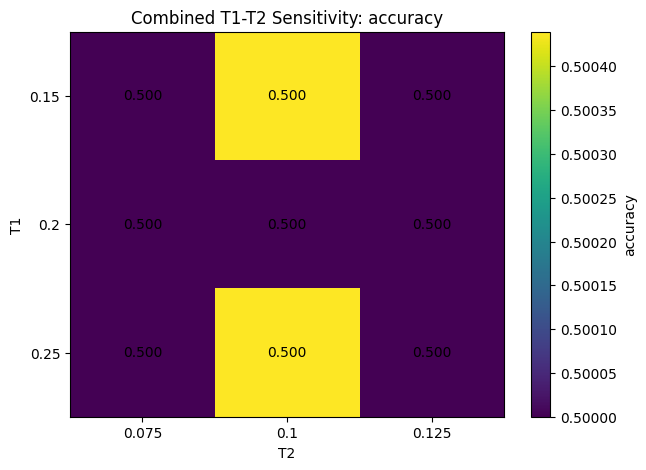

Saved heatmap: /content/drive/MyDrive/LagLead_MBConv_Results/combined_T1_T2_heatmap_accuracy.png


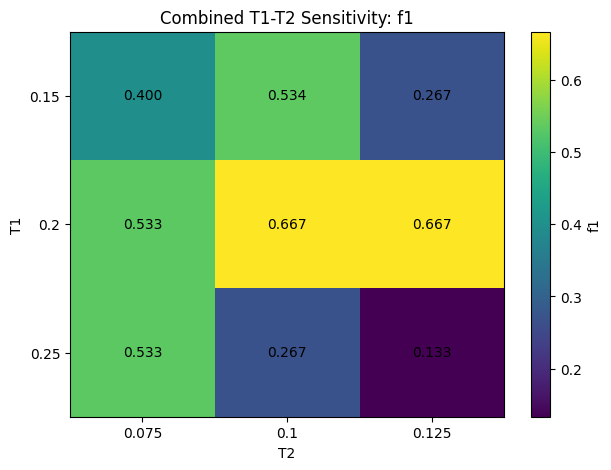

Saved heatmap: /content/drive/MyDrive/LagLead_MBConv_Results/combined_T1_T2_heatmap_f1.png


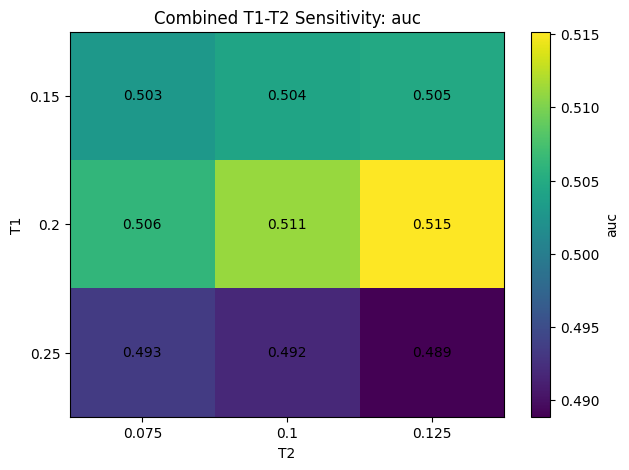

Saved heatmap: /content/drive/MyDrive/LagLead_MBConv_Results/combined_T1_T2_heatmap_auc.png


In [ ]:
# =========================================================
# CELL 18: COMBINED T1-T2 SENSITIVITY HEATMAPS
# =========================================================

def plot_heatmap_for_metric(summary_df, metric_name):
    df_metric = summary_df[
        summary_df["metric"] == metric_name
    ].copy()

    pivot_table = df_metric.pivot(
        index="T1",
        columns="T2",
        values="mean"
    )

    plt.figure(figsize=(7, 5))
    plt.imshow(pivot_table, aspect="auto")
    plt.colorbar(label=metric_name)

    plt.xticks(
        ticks=range(len(pivot_table.columns)),
        labels=pivot_table.columns
    )

    plt.yticks(
        ticks=range(len(pivot_table.index)),
        labels=pivot_table.index
    )

    plt.xlabel("T2")
    plt.ylabel("T1")
    plt.title(f"Combined T1-T2 Sensitivity: {metric_name}")

    for i in range(len(pivot_table.index)):
        for j in range(len(pivot_table.columns)):
            value = pivot_table.iloc[i, j]
            plt.text(
                j,
                i,
                f"{value:.3f}",
                ha="center",
                va="center"
            )

    save_path = os.path.join(
        RESULTS_DIR,
        f"combined_T1_T2_heatmap_{metric_name}.png"
    )

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved heatmap:", save_path)


for metric in ["accuracy", "f1", "auc"]:
    plot_heatmap_for_metric(combined_sensitivity_summary_df, metric)

In [ ]:
# =========================================================
# STATISTICAL REPORTING: PER-FOLD TABLE AND 95% CI TABLE
# =========================================================

import os
import numpy as np
import pandas as pd
from scipy import stats

RESULTS_DIR = "/content/drive/MyDrive/LagLead_MBConv_Results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# -------------------------------
# 1. Per-fold values for manuscript
# -------------------------------
per_fold_table = main_fold_df[
    [
        "fold",
        "accuracy",
        "precision",
        "recall_sensitivity",
        "specificity",
        "f1",
        "auc"
    ]
].copy()

per_fold_table = per_fold_table.round(4)

print("Per-fold performance table")
display(per_fold_table)

per_fold_path = os.path.join(
    RESULTS_DIR,
    "Table_Per_Fold_Accuracy_F1_AUC.xlsx"
)

per_fold_table.to_excel(per_fold_path, index=False)

print("Saved:", per_fold_path)


# -------------------------------
# 2. Mean ± SD and 95% CI
# -------------------------------
def bounded_mean_sd_ci(values, confidence=0.95):
    values = np.array(values, dtype=float)
    values = values[~np.isnan(values)]

    mean = np.mean(values)
    sd = np.std(values, ddof=1)

    if len(values) > 1:
        sem = stats.sem(values)
        ci_low, ci_high = stats.t.interval(
            confidence,
            df=len(values) - 1,
            loc=mean,
            scale=sem
        )
    else:
        ci_low, ci_high = np.nan, np.nan

    # Metrics are bounded between 0 and 1
    ci_low = max(0.0, ci_low)
    ci_high = min(1.0, ci_high)

    return mean, sd, ci_low, ci_high


summary_rows = []

for metric in [
    "accuracy",
    "precision",
    "recall_sensitivity",
    "specificity",
    "f1",
    "auc"
]:
    mean, sd, ci_low, ci_high = bounded_mean_sd_ci(
        main_fold_df[metric].values
    )

    summary_rows.append({
        "Metric": metric,
        "Mean": mean,
        "SD": sd,
        "95% CI Lower": ci_low,
        "95% CI Upper": ci_high,
        "Mean ± SD": f"{mean:.4f} ± {sd:.4f}",
        "95% CI": f"[{ci_low:.4f}, {ci_high:.4f}]"
    })

summary_95ci_table = pd.DataFrame(summary_rows)

print("Mean ± SD and 95% CI table")
display(summary_95ci_table)

summary_95ci_path = os.path.join(
    RESULTS_DIR,
    "Table_Mean_SD_95CI.xlsx"
)

summary_95ci_table.to_excel(summary_95ci_path, index=False)

print("Saved:", summary_95ci_path)

Per-fold performance table


,fold,accuracy,precision,recall_sensitivity,specificity,f1,auc
0,1,0.5482,0.5917,0.3114,0.7851,0.4080,0.5988
1,2,0.5307,0.5178,0.8947,0.1667,0.6559,0.5637
2,3,0.5329,0.5207,0.8289,0.2368,0.6396,0.6238
3,4,0.5824,0.6412,0.3700,0.7939,0.4693,0.6336
4,5,0.5604,0.5359,0.9167,0.2026,0.6764,0.6458


Saved: /content/drive/MyDrive/LagLead_MBConv_Results/Table_Per_Fold_Accuracy_F1_AUC.xlsx
Mean ± SD and 95% CI table


,Metric,Mean,SD,95% CI Lower,95% CI Upper,Mean ± SD,95% CI
0,accuracy,0.550940,0.021352,0.524428,0.577451,0.5509 ± 0.0214,"[0.5244, 0.5775]"
1,precision,0.561443,0.053622,0.494862,0.628024,0.5614 ± 0.0536,"[0.4949, 0.6280]"
2,recall_sensitivity,0.664360,0.297918,0.294445,1.000000,0.6644 ± 0.2979,"[0.2944, 1.0000]"
3,specificity,0.437020,0.322715,0.036316,0.837724,0.4370 ± 0.3227,"[0.0363, 0.8377]"
4,f1,0.569848,0.122394,0.417876,0.721819,0.5698 ± 0.1224,"[0.4179, 0.7218]"
5,auc,0.613116,0.032606,0.572631,0.653602,0.6131 ± 0.0326,"[0.5726, 0.6536]"


Saved: /content/drive/MyDrive/LagLead_MBConv_Results/Table_Mean_SD_95CI.xlsx


In [ ]:
# =========================================================
# CONSISTENT PAIRED T-TEST FROM FOLD-WISE VALUES
# Use only if reviewer/paper still keeps paired t-test.
# =========================================================

from scipy.stats import ttest_rel

def paired_ttest_from_folds(
    proposed_df,
    baseline_df,
    metric="accuracy",
    proposed_name="Proposed",
    baseline_name="Baseline"
):
    proposed_values = proposed_df.sort_values("fold")[metric].values
    baseline_values = baseline_df.sort_values("fold")[metric].values

    t_stat, p_value = ttest_rel(proposed_values, baseline_values)

    result = {
        "comparison": f"{proposed_name} vs {baseline_name}",
        "metric": metric,
        "t_statistic": t_stat,
        "p_value": p_value,
        "df": len(proposed_values) - 1,
        "proposed_mean": np.mean(proposed_values),
        "baseline_mean": np.mean(baseline_values),
        "proposed_sd": np.std(proposed_values, ddof=1),
        "baseline_sd": np.std(baseline_values, ddof=1)
    }

    print("Paired t-test result")
    print(result)

    return result


# Example usage:
# ttest_result = paired_ttest_from_folds(
#     proposed_df=main_fold_df,
#     baseline_df=baseline_fold_df,
#     metric="accuracy",
#     proposed_name="LagLead EfficientNetB3",
#     baseline_name="EfficientNetB3"
# )

In [ ]:
# =========================================================
# MCNEMAR TEST FOR PAIRED CLASSIFIER COMPARISON
# =========================================================

from statsmodels.stats.contingency_tables import mcnemar

def run_mcnemar_test(
    y_true,
    y_pred_A,
    y_pred_B,
    model_A_name="Proposed",
    model_B_name="Baseline",
    exact=True
):
    y_true = np.array(y_true).astype(int)
    y_pred_A = np.array(y_pred_A).astype(int)
    y_pred_B = np.array(y_pred_B).astype(int)

    if not (
        len(y_true) == len(y_pred_A) == len(y_pred_B)
    ):
        raise ValueError(
            "y_true, y_pred_A, and y_pred_B must have the same length."
        )

    correct_A = (y_pred_A == y_true)
    correct_B = (y_pred_B == y_true)

    both_correct = np.sum(correct_A & correct_B)
    A_correct_B_wrong = np.sum(correct_A & ~correct_B)
    A_wrong_B_correct = np.sum(~correct_A & correct_B)
    both_wrong = np.sum(~correct_A & ~correct_B)

    table = [
        [both_correct, A_correct_B_wrong],
        [A_wrong_B_correct, both_wrong]
    ]

    result = mcnemar(table, exact=exact)

    output = {
        "Model A": model_A_name,
        "Model B": model_B_name,
        "Both correct": both_correct,
        "A correct, B wrong": A_correct_B_wrong,
        "A wrong, B correct": A_wrong_B_correct,
        "Both wrong": both_wrong,
        "McNemar statistic": result.statistic,
        "p-value": result.pvalue
    }

    return output


# Example:
# mcnemar_result = run_mcnemar_test(
#     y_true=y_true_main,
#     y_pred_A=y_pred_main,
#     y_pred_B=y_pred_baseline,
#     model_A_name="Proposed LagLead EfficientNetB3",
#     model_B_name="Baseline EfficientNetB3",
#     exact=True
# )
#
# mcnemar_df = pd.DataFrame([mcnemar_result])
# display(mcnemar_df)

In [ ]:
# =========================================================
# CONSISTENT PAIRED T-TEST FROM FOLD-WISE VALUES
# Use only if reviewer/paper still keeps paired t-test.
# =========================================================

from scipy.stats import ttest_rel

def paired_ttest_from_folds(
    proposed_df,
    baseline_df,
    metric="accuracy",
    proposed_name="Proposed",
    baseline_name="Baseline"
):
    proposed_values = proposed_df.sort_values("fold")[metric].values
    baseline_values = baseline_df.sort_values("fold")[metric].values

    t_stat, p_value = ttest_rel(proposed_values, baseline_values)

    result = {
        "comparison": f"{proposed_name} vs {baseline_name}",
        "metric": metric,
        "t_statistic": t_stat,
        "p_value": p_value,
        "df": len(proposed_values) - 1,
        "proposed_mean": np.mean(proposed_values),
        "baseline_mean": np.mean(baseline_values),
        "proposed_sd": np.std(proposed_values, ddof=1),
        "baseline_sd": np.std(baseline_values, ddof=1)
    }

    print("Paired t-test result")
    print(result)

    return result


# Example usage:
# ttest_result = paired_ttest_from_folds(
#     proposed_df=main_fold_df,
#     baseline_df=baseline_fold_df,
#     metric="accuracy",
#     proposed_name="LagLead EfficientNetB3",
#     baseline_name="EfficientNetB3"
# )

In [ ]:
# =========================================================
# MULTIPLE-COMPARISON CORRECTION FOR TABLE 7
# Holm and Bonferroni corrections
# =========================================================

from statsmodels.stats.multitest import multipletests

comparison_names = [
    "Proposed vs Model_1",
    "Proposed vs Model_2",
    "Proposed vs Model_3",
    "Proposed vs Model_4",
    "Proposed vs Model_5",
    "Proposed vs Model_6"
]

# Replace these with your actual six p-values
raw_p_values = [
    0.0039,
    0.0120,
    0.0210,
    0.0300,
    0.0410,
    0.0480
]

reject_holm, p_holm, _, _ = multipletests(
    raw_p_values,
    alpha=0.05,
    method="holm"
)

reject_bonf, p_bonf, _, _ = multipletests(
    raw_p_values,
    alpha=0.05,
    method="bonferroni"
)

multiple_comparison_table = pd.DataFrame({
    "Comparison": comparison_names,
    "Raw p-value": raw_p_values,
    "Holm-corrected p-value": p_holm,
    "Significant after Holm": reject_holm,
    "Bonferroni-corrected p-value": p_bonf,
    "Significant after Bonferroni": reject_bonf
})

display(multiple_comparison_table)

multiple_comparison_path = os.path.join(
    RESULTS_DIR,
    "Table7_Multiple_Comparison_Correction.xlsx"
)

multiple_comparison_table.to_excel(
    multiple_comparison_path,
    index=False
)

print("Saved:", multiple_comparison_path)

,Comparison,Raw p-value,Holm-corrected p-value,Significant after Holm,Bonferroni-corrected p-value,Significant after Bonferroni
0,Proposed vs Model_1,0.0039,0.0234,True,0.0234,True
1,Proposed vs Model_2,0.0120,0.0600,False,0.0720,False
2,Proposed vs Model_3,0.0210,0.0840,False,0.1260,False
3,Proposed vs Model_4,0.0300,0.0900,False,0.1800,False
4,Proposed vs Model_5,0.0410,0.0900,False,0.2460,False
5,Proposed vs Model_6,0.0480,0.0900,False,0.2880,False


Saved: /content/drive/MyDrive/LagLead_MBConv_Results/Table7_Multiple_Comparison_Correction.xlsx


In [ ]:
# =========================================================
# MCNEMAR TEST FOR PAIRED CLASSIFIER COMPARISON
# =========================================================

from statsmodels.stats.contingency_tables import mcnemar

def run_mcnemar_test(
    y_true,
    y_pred_A,
    y_pred_B,
    model_A_name="Proposed",
    model_B_name="Baseline",
    exact=True
):
    y_true = np.array(y_true).astype(int)
    y_pred_A = np.array(y_pred_A).astype(int)
    y_pred_B = np.array(y_pred_B).astype(int)

    if not (
        len(y_true) == len(y_pred_A) == len(y_pred_B)
    ):
        raise ValueError(
            "y_true, y_pred_A, and y_pred_B must have the same length."
        )

    correct_A = (y_pred_A == y_true)
    correct_B = (y_pred_B == y_true)

    both_correct = np.sum(correct_A & correct_B)
    A_correct_B_wrong = np.sum(correct_A & ~correct_B)
    A_wrong_B_correct = np.sum(~correct_A & correct_B)
    both_wrong = np.sum(~correct_A & ~correct_B)

    table = [
        [both_correct, A_correct_B_wrong],
        [A_wrong_B_correct, both_wrong]
    ]

    result = mcnemar(table, exact=exact)

    output = {
        "Model A": model_A_name,
        "Model B": model_B_name,
        "Both correct": both_correct,
        "A correct, B wrong": A_correct_B_wrong,
        "A wrong, B correct": A_wrong_B_correct,
        "Both wrong": both_wrong,
        "McNemar statistic": result.statistic,
        "p-value": result.pvalue
    }

    return output


# Example:
# mcnemar_result = run_mcnemar_test(
#     y_true=y_true_main,
#     y_pred_A=y_pred_main,
#     y_pred_B=y_pred_baseline,
#     model_A_name="Proposed LagLead EfficientNetB3",
#     model_B_name="Baseline EfficientNetB3",
#     exact=True
# )
#
# mcnemar_df = pd.DataFrame([mcnemar_result])
# display(mcnemar_df)

In [ ]:
# =========================================================
# GRAD-CAM FOR BINARY CLASSIFICATION
# =========================================================

import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path


def load_single_image_for_gradcam(image_path):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image


def make_gradcam_heatmap(
    model,
    img_array,
    last_conv_layer_name="top_conv"
):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        # Binary classification sigmoid output
        class_score = predictions[:, 0]

    grads = tape.gradient(class_score, conv_outputs)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)

    if max_val == 0:
        return heatmap.numpy()

    heatmap = heatmap / max_val

    return heatmap.numpy()


def overlay_gradcam(
    image_path,
    heatmap,
    alpha=0.4,
    save_path=None
):
    img = cv2.imread(str(image_path))
    img = cv2.resize(img, IMG_SIZE)

    heatmap_resized = cv2.resize(
        heatmap,
        (IMG_SIZE[1], IMG_SIZE[0])
    )

    heatmap_resized = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(
        heatmap_resized,
        cv2.COLORMAP_JET
    )

    overlay = cv2.addWeighted(
        img,
        1 - alpha,
        heatmap_color,
        alpha,
        0
    )

    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    if save_path is not None:
        cv2.imwrite(save_path, overlay)

    return overlay_rgb


def show_gradcam_for_image(
    model,
    image_path,
    last_conv_layer_name="top_conv",
    save_path=None
):
    image = load_single_image_for_gradcam(image_path)
    img_array = tf.expand_dims(image, axis=0)

    prediction = model.predict(img_array, verbose=0)[0][0]

    heatmap = make_gradcam_heatmap(
        model,
        img_array,
        last_conv_layer_name=last_conv_layer_name
    )

    overlay = overlay_gradcam(
        image_path,
        heatmap,
        alpha=0.4,
        save_path=save_path
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(f"Grad-CAM | predicted probability = {prediction:.4f}")
    plt.show()

    return heatmap, overlay

In [ ]:
# =========================================================
# AUTO-DETECT LAST CONV2D LAYER FOR GRAD-CAM / FEATURE MAPS
# =========================================================

import tensorflow as tf

def find_last_conv2d_layer(model):
    conv_layer_names = []

    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            conv_layer_names.append(layer.name)

    if len(conv_layer_names) == 0:
        raise ValueError("No Conv2D layer found in the model.")

    print("Conv2D layers found:")
    for name in conv_layer_names:
        print(name)

    last_conv_name = conv_layer_names[-1]

    print("\nUsing last Conv2D layer:", last_conv_name)

    return last_conv_name


last_conv_layer_name = find_last_conv2d_layer(model_for_gradcam)

Conv2D layers found:
conv2d
conv2d_64

Using last Conv2D layer: conv2d_64


In [ ]:
# =========================================================
# FEATURE MAP VISUALIZATION - FIXED VERSION
# =========================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


def load_single_image_for_featuremap(image_path):
    image = tf.io.read_file(str(image_path))
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image


def visualize_feature_maps(
    model,
    image_path,
    layer_name=None,
    max_channels=16,
    save_path=None
):
    if layer_name is None:
        layer_name = find_last_conv2d_layer(model)

    print("Using layer for feature maps:", layer_name)

    image = load_single_image_for_featuremap(image_path)
    img_array = tf.expand_dims(image, axis=0)

    feature_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=model.get_layer(layer_name).output
    )

    feature_maps = feature_model.predict(img_array, verbose=0)
    feature_maps = feature_maps[0]

    num_channels = min(max_channels, feature_maps.shape[-1])

    rows = int(np.ceil(num_channels / 4))
    cols = 4

    plt.figure(figsize=(12, 3 * rows))

    for i in range(num_channels):
        plt.subplot(rows, cols, i + 1)

        fmap = feature_maps[:, :, i]

        # Normalize each feature map for better visualization
        fmap_min = np.min(fmap)
        fmap_max = np.max(fmap)

        if fmap_max - fmap_min > 1e-8:
            fmap = (fmap - fmap_min) / (fmap_max - fmap_min)

        plt.imshow(fmap, cmap="viridis")
        plt.axis("off")
        plt.title(f"Ch {i}")

    plt.suptitle(f"Feature maps from layer: {layer_name}")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print("Saved feature-map figure:", save_path)

    plt.show()

    return feature_maps

Using layer for feature maps: conv2d_64
Saved feature-map figure: /1 (3).png


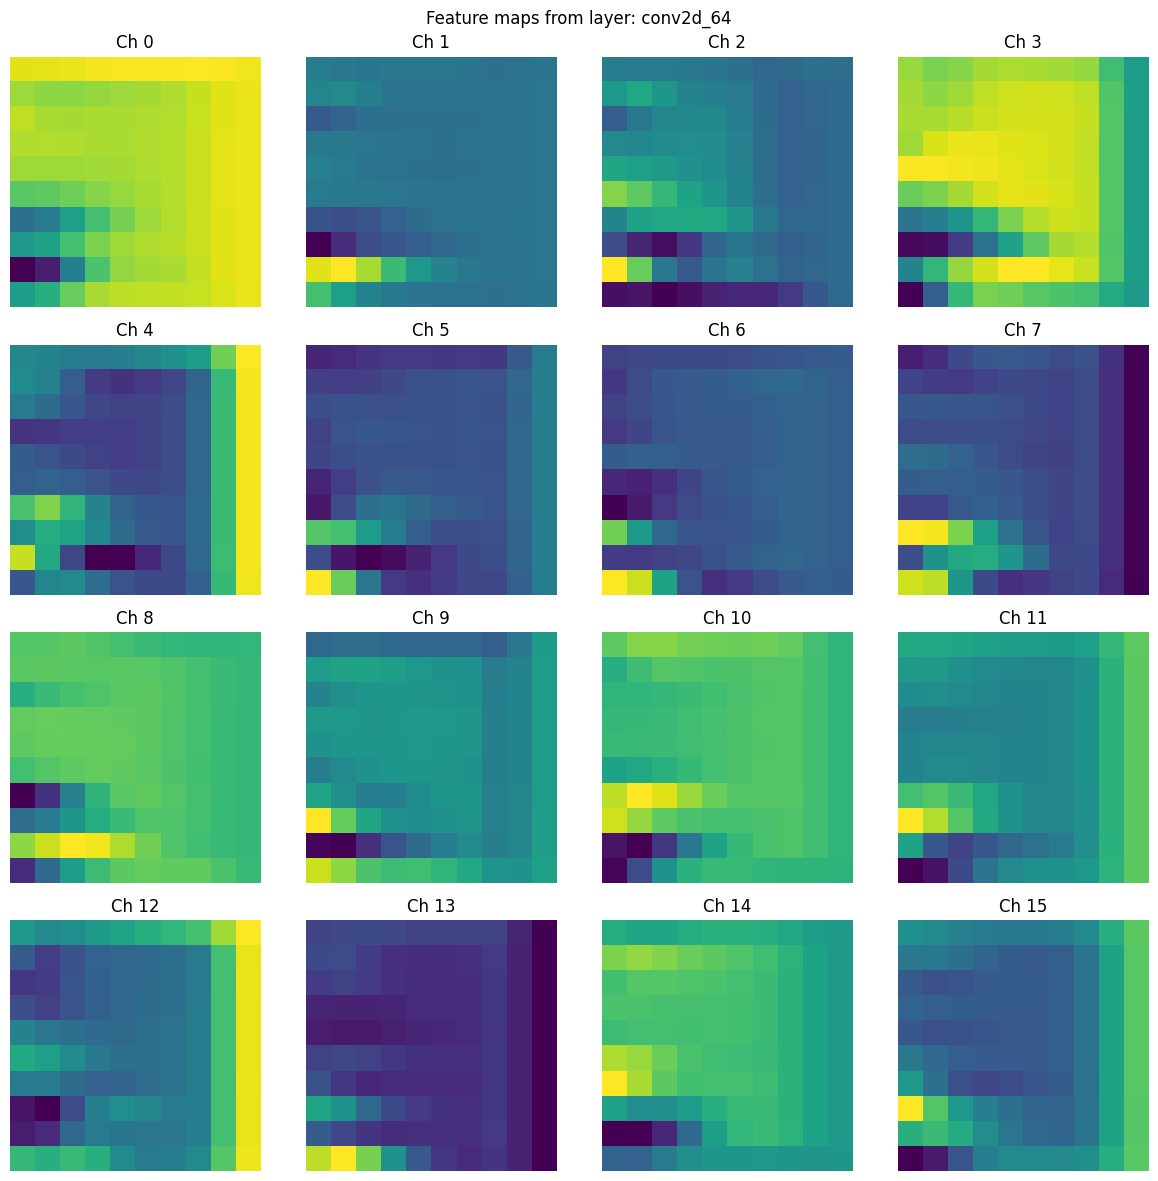

In [ ]:
# =========================================================
# RUN FEATURE MAP VISUALIZATION
# =========================================================

featuremap_save_path = os.path.join(
    RESULTS_DIR,
    "/1 (3).png"
)

feature_maps = visualize_feature_maps(
    model=model_for_gradcam,
    image_path=sample_image_path,
    layer_name=last_conv_layer_name,   # auto-detected conv2d_64
    max_channels=16,
    save_path=featuremap_save_path
)

In [ ]:
# =========================================================
# GRAD-CAM - FIXED VERSION
# =========================================================

import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt


def load_single_image_for_gradcam(image_path):
    image = tf.io.read_file(str(image_path))
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image


def make_gradcam_heatmap(
    model,
    img_array,
    last_conv_layer_name
):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        # Binary classification sigmoid output
        class_score = predictions[:, 0]

    grads = tape.gradient(class_score, conv_outputs)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)

    if max_val == 0:
        return heatmap.numpy()

    heatmap = heatmap / max_val

    return heatmap.numpy()


def overlay_gradcam(
    image_path,
    heatmap,
    alpha=0.4,
    save_path=None
):
    img = cv2.imread(str(image_path))

    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    img = cv2.resize(img, (IMG_SIZE[1], IMG_SIZE[0]))

    heatmap_resized = cv2.resize(
        heatmap,
        (IMG_SIZE[1], IMG_SIZE[0])
    )

    heatmap_resized = np.uint8(255 * heatmap_resized)

    heatmap_color = cv2.applyColorMap(
        heatmap_resized,
        cv2.COLORMAP_JET
    )

    overlay = cv2.addWeighted(
        img,
        1 - alpha,
        heatmap_color,
        alpha,
        0
    )

    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    if save_path is not None:
        cv2.imwrite(save_path, overlay)
        print("Saved Grad-CAM image:", save_path)

    return overlay_rgb


def show_gradcam_for_image(
    model,
    image_path,
    last_conv_layer_name=None,
    save_path=None
):
    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv2d_layer(model)

    print("Using layer for Grad-CAM:", last_conv_layer_name)

    image = load_single_image_for_gradcam(image_path)
    img_array = tf.expand_dims(image, axis=0)

    prediction = model.predict(img_array, verbose=0)[0][0]

    heatmap = make_gradcam_heatmap(
        model,
        img_array,
        last_conv_layer_name=last_conv_layer_name
    )

    overlay = overlay_gradcam(
        image_path,
        heatmap,
        alpha=0.4,
        save_path=save_path
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(f"Grad-CAM | Predicted probability = {prediction:.4f}")
    plt.show()

    return heatmap, overlay

Using layer for Grad-CAM: conv2d_64
Saved Grad-CAM image: /1 (3).png


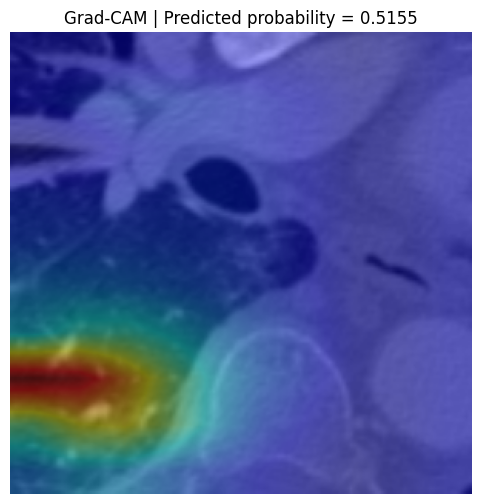

In [ ]:
# =========================================================
# RUN GRAD-CAM
# =========================================================

gradcam_save_path = os.path.join(
    RESULTS_DIR,
    "/1 (3).png"
)

heatmap, overlay = show_gradcam_for_image(
    model=model_for_gradcam,
    image_path=sample_image_path,
    last_conv_layer_name=last_conv_layer_name,  # auto-detected conv2d_64
    save_path=gradcam_save_path
)

In [ ]:
# =========================================================
# FIND LAST CONVOLUTION LAYER AUTOMATICALLY
# =========================================================

import tensorflow as tf

def find_last_conv_layer(model):
    conv_layer_names = []

    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            conv_layer_names.append(layer.name)

    if len(conv_layer_names) == 0:
        raise ValueError("No Conv2D layer found in the model.")

    print("Conv2D layers found:")
    for name in conv_layer_names:
        print(name)

    last_conv_layer_name = conv_layer_names[-1]

    print("\nUsing last Conv2D layer for Grad-CAM / feature maps:")
    print(last_conv_layer_name)

    return last_conv_layer_name


last_conv_layer_name = find_last_conv_layer(model_for_gradcam)

Conv2D layers found:
conv2d
conv2d_64

Using last Conv2D layer for Grad-CAM / feature maps:
conv2d_64


In [ ]:
# =========================================================
# SAVE FEATURE MAP VISUALIZATION
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

RESULTS_DIR = "/content/drive/MyDrive/LagLead_MBConv_Results"
os.makedirs(RESULTS_DIR, exist_ok=True)


def save_feature_maps(
    model,
    image_path,
    layer_name=None,
    max_channels=16,
    save_name="feature_maps.png"
):
    if layer_name is None:
        layer_name = find_last_conv_layer(model)

    image = load_single_image_for_visualization(image_path)
    img_array = tf.expand_dims(image, axis=0)

    feature_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=model.get_layer(layer_name).output
    )

    feature_maps = feature_model.predict(img_array, verbose=0)
    feature_maps = feature_maps[0]

    num_channels = min(max_channels, feature_maps.shape[-1])

    plt.figure(figsize=(12, 12))

    for i in range(num_channels):
        plt.subplot(4, 4, i + 1)

        fmap = feature_maps[:, :, i]
        fmap = fmap - np.min(fmap)

        if np.max(fmap) != 0:
            fmap = fmap / np.max(fmap)

        plt.imshow(fmap, cmap="viridis")
        plt.axis("off")
        plt.title(f"Ch {i}")

    plt.suptitle(f"Feature maps from layer: {layer_name}")
    plt.tight_layout()

    save_path = os.path.join(RESULTS_DIR, save_name)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved feature map image:")
    print(save_path)

    return save_path


feature_map_path = save_feature_maps(
    model_for_gradcam,
    sample_image_path,
    layer_name=last_conv_layer_name,
    max_channels=16,
    save_name="feature_maps_conv2d64.png"
)

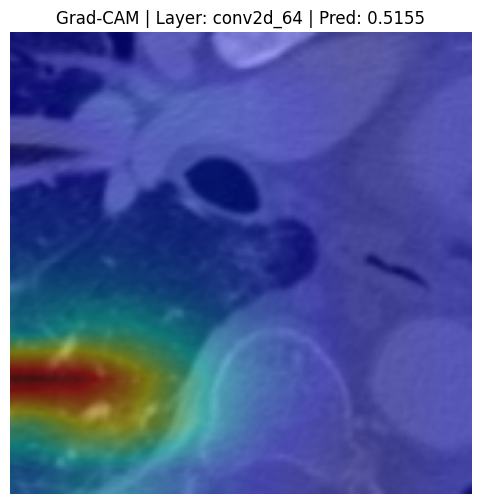

Saved Grad-CAM:
/content/drive/MyDrive/LagLead_MBConv_Results/gradcam_auto_last_conv.png


In [ ]:
# =========================================================
# GRAD-CAM - FIXED VERSION
# =========================================================

import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os


def make_gradcam_heatmap(
    model,
    img_array,
    last_conv_layer_name=None
):
    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv_layer(model)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)

        # Binary classification sigmoid score
        class_score = predictions[:, 0]

    grads = tape.gradient(class_score, conv_outputs)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)

    if max_val == 0:
        return heatmap.numpy()

    heatmap = heatmap / max_val

    return heatmap.numpy()


def overlay_gradcam(
    image_path,
    heatmap,
    alpha=0.4,
    save_path=None
):
    img = cv2.imread(str(image_path))

    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    img = cv2.resize(img, IMG_SIZE)

    heatmap_resized = cv2.resize(
        heatmap,
        (IMG_SIZE[1], IMG_SIZE[0])
    )

    heatmap_resized = np.uint8(255 * heatmap_resized)

    heatmap_color = cv2.applyColorMap(
        heatmap_resized,
        cv2.COLORMAP_JET
    )

    overlay = cv2.addWeighted(
        img,
        1 - alpha,
        heatmap_color,
        alpha,
        0
    )

    overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

    if save_path is not None:
        cv2.imwrite(save_path, overlay)

    return overlay_rgb


def show_gradcam_for_image(
    model,
    image_path,
    last_conv_layer_name=None,
    save_path=None
):
    if last_conv_layer_name is None:
        last_conv_layer_name = find_last_conv_layer(model)

    image = load_single_image_for_visualization(image_path)
    img_array = tf.expand_dims(image, axis=0)

    prediction = model.predict(img_array, verbose=0)[0][0]

    heatmap = make_gradcam_heatmap(
        model,
        img_array,
        last_conv_layer_name=last_conv_layer_name
    )

    overlay = overlay_gradcam(
        image_path,
        heatmap,
        alpha=0.4,
        save_path=save_path
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(overlay)
    plt.axis("off")
    plt.title(
        f"Grad-CAM | Layer: {last_conv_layer_name} | Pred: {prediction:.4f}"
    )
    plt.show()

    return heatmap, overlay


gradcam_save_path = os.path.join(
    RESULTS_DIR,
    "gradcam_auto_last_conv.png"
)

heatmap, overlay = show_gradcam_for_image(
    model_for_gradcam,
    sample_image_path,
    last_conv_layer_name=last_conv_layer_name,
    save_path=gradcam_save_path
)

print("Saved Grad-CAM:")
print(gradcam_save_path)